# **Bags of Words and Weighing Schemes**

There are aggressive and non-aggressive tweets in the training and validation files, as well as their labels. Here, an example of classification is given using Bag of Words.

In [1]:
# Libraries.
import numpy as np                               # library for numerical operations.
import matplotlib.pyplot as plt                  # library for plotting.          
import nltk                                      # library for text processing.
from collections import Counter                  # library for counting.
from nltk.tokenize import TweetTokenizer         # library for tokenizing.
from sklearn import svm, metrics                 # library for machine learning.
from sklearn.model_selection import GridSearchCV # library for hyperparameter tuning.
import seaborn as sns                            # library for plotting.
from collections import defaultdict              # library for counting.
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix # library for evaluation.


In [2]:
def get_text_from_file(path_corpus: str, path_labels: str) -> tuple:
    """
    Read the text and labels from the files.

    Parameters
    ----------
    path_corpus : str
        Path to the file containing the text.
    path_labels : str
        Path to the file containing the labels.

    Returns
    -------
    tuple
        A tuple containing the text and labels.
    """
    with open(path_corpus, 'r', encoding = 'utf-8') as f_corpus, open(path_labels, 'r', encoding = 'utf-8') as f_labels:
        tr_txt = f_corpus.readlines()               # Read the text line by line.
        tr_y = list(map(int, f_labels.readlines())) # Read the labels line by line.
    return tr_txt, tr_y

# Load the data.
tr_txt, tr_y   = get_text_from_file('./mex20_train.txt', './mex20_train_labels.txt') # Training data.
val_txt, val_y = get_text_from_file('./mex20_val.txt', './mex20_val_labels.txt')     # Validation data.

In [3]:
# Print the first 5 samples.
tr_txt[:5]

['@USUARIO @USUARIO @USUARIO Q se puede esperar del maricon de closet de la Yañez aun recuerdo esa ves q lo vi en zona rosa viendo quien lo levantada\n',
 '@USUARIO La piel nueva siempre arde un poquito los primeros días... y más con este puto clima\n',
 'Ustedes no se enamoran de mí… por tontas.\n',
 'Me las va a pagar esa puta gorda roba tuits...\n',
 '@USUARIO LA GENTE ES TONTA PORQUE NO SE DAN CUENTA QUE TÚ HACES A BATMAN AZUL\n']

## **Estadísticas Simples**

**How ​​many examples of each class are there? (Labels in the data set) and histogram with the counter**

In [4]:
print("Number of samples per class in the training data:\n", Counter(tr_y))
print("Number of samples per class in the validation data:\n", Counter(val_y))

Number of samples per class in the training data:
 Counter({0: 3759, 1: 1519})
Number of samples per class in the validation data:
 Counter({0: 418, 1: 169})


**Class distribution visualization**

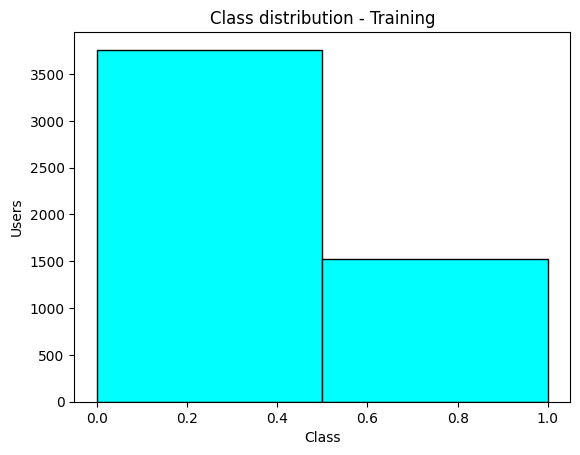

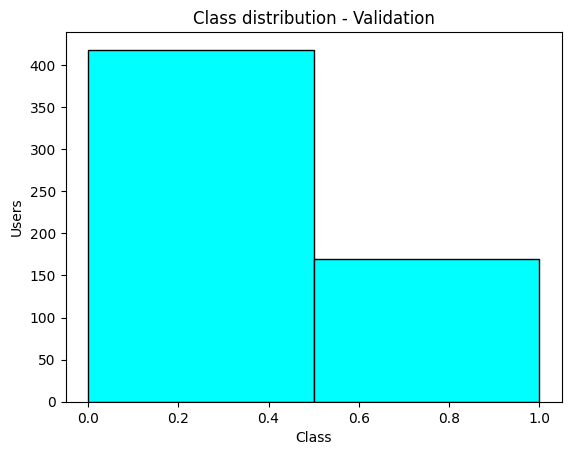

In [5]:
for dataset, title in [(tr_y, 'Training'), (val_y, 'Validation')]:
    plt.hist(dataset, bins = len(set(dataset)), color = 'cyan', edgecolor = 'black')
    plt.xlabel('Class')
    plt.ylabel('Users')
    plt.title(f'Class distribution - {title}')
    plt.show()

## **Simple vocabulary construction**

No longer do we want lists of strings, but lists of words (tokens) using NLTK

In [6]:
# Tokenization and word counting.
tokenizer = TweetTokenizer()                                        # Create a tokenizer.
corpus_words = [tokenizer.tokenize(doc) for doc in tr_txt]          # Tokenize the text.
fdist = nltk.FreqDist(word for doc in corpus_words for word in doc) # Frequency distribution.
print("Vocabulary size  :", len(fdist))
print("Most common words:", fdist.most_common(10))
fdist

Vocabulary size  : 15194
Most common words: [(',', 3016), ('de', 2915), ('que', 2829), ('.', 2604), ('la', 2031), ('a', 1956), ('y', 1856), ('!', 1435), ('no', 1430), ('@USUARIO', 1399)]


FreqDist({',': 3016, 'de': 2915, 'que': 2829, '.': 2604, 'la': 2031, 'a': 1956, 'y': 1856, '!': 1435, 'no': 1430, '@USUARIO': 1399, ...})

## **Creating the dictionary**

It has as its key the ranking of the word according to its frequency, i.e., the first is the most frequent, etc.

In [7]:
# Selection of the 5000 most frequent words
top_words = [word for word, _ in fdist.most_common(5000)]    # Select the 5000 most frequent words.
dict_indices = {word: i for i, word in enumerate(top_words)} # Create a dictionary with the indices of the words.

print(top_words)
dict_indices

[',', 'de', 'que', '.', 'la', 'a', 'y', '!', 'no', '@USUARIO', 'me', 'el', 'en', 'se', 'es', 'con', '?', 'verga', 'los', 'madre', 'por', 'las', '"', 'un', 'te', 'mi', 'lo', 'putas', 'una', '...', 'putos', 'para', '😂', 'si', 'ya', 'como', 'su', 'pero', 'tu', 'loca', 'le', 'más', 'No', 'del', 'gorda', 'al', 'bien', 'A', '¿', 'Y', 'Me', 'son', 'o', 'cuando', 'feas', 'Que', ':', 'yo', 'les', 'porque', 'está', 'ni', 'ser', 'estoy', 'sus', 'todos', 'esta', 'puta', 'Ya', 'todo', 'pinche', 'puto', 'tan', 'La', 'Si', 'qué', '…', 'eso', 'muy', 'soy', 'hasta', 'así', '¡', '<URL>', 'mamar', 'hay', 'q', 'DE', 'mis', 'joto', 'este', 'cosas', 'hace', '️', 'nos', 'vida', 'ver', 'mejor', 'solo', 'nada', 'vale', 'va', 'eres', 'quiero', 'marica', 'día', 'siempre', 'esa', 'voy', 'gente', 'Yo', 'vez', 'El', '😭', '-', 'mierda', 'tengo', '(', ')', 'sin', 'ese', 'Es', 'luchona', '😍', 'hdp', 'ahora', 'Por', '😡', '“', 'tienen', 'tiene', 'pinches', 'hacer', 'tontas', 'LA', 'tus', 'Como', '”', 'gusta', 'sea', 'HD

{',': 0,
 'de': 1,
 'que': 2,
 '.': 3,
 'la': 4,
 'a': 5,
 'y': 6,
 '!': 7,
 'no': 8,
 '@USUARIO': 9,
 'me': 10,
 'el': 11,
 'en': 12,
 'se': 13,
 'es': 14,
 'con': 15,
 '?': 16,
 'verga': 17,
 'los': 18,
 'madre': 19,
 'por': 20,
 'las': 21,
 '"': 22,
 'un': 23,
 'te': 24,
 'mi': 25,
 'lo': 26,
 'putas': 27,
 'una': 28,
 '...': 29,
 'putos': 30,
 'para': 31,
 '😂': 32,
 'si': 33,
 'ya': 34,
 'como': 35,
 'su': 36,
 'pero': 37,
 'tu': 38,
 'loca': 39,
 'le': 40,
 'más': 41,
 'No': 42,
 'del': 43,
 'gorda': 44,
 'al': 45,
 'bien': 46,
 'A': 47,
 '¿': 48,
 'Y': 49,
 'Me': 50,
 'son': 51,
 'o': 52,
 'cuando': 53,
 'feas': 54,
 'Que': 55,
 ':': 56,
 'yo': 57,
 'les': 58,
 'porque': 59,
 'está': 60,
 'ni': 61,
 'ser': 62,
 'estoy': 63,
 'sus': 64,
 'todos': 65,
 'esta': 66,
 'puta': 67,
 'Ya': 68,
 'todo': 69,
 'pinche': 70,
 'puto': 71,
 'tan': 72,
 'La': 73,
 'Si': 74,
 'qué': 75,
 '…': 76,
 'eso': 77,
 'muy': 78,
 'soy': 79,
 'hasta': 80,
 'así': 81,
 '¡': 82,
 '<URL>': 83,
 'mamar': 84,


## **Bag of Words**

In [8]:
def build_bow_binary_weights(docs: list, vocab: list, word_index: dict) -> np.ndarray:
    """
    Build a bag of words matrix. Rows are documents and columns are words. 1 means that the word is present in the
    document and 0 means that the word is not present in the document.

    Parameters
    ----------
    docs : list
        List of documents.
    vocab : list
        List of words.
    word_index : dict
        Dictionary with the indices of the words.

    Returns
    -------
    np.ndarray
        Bag of words matrix.
    """
    bow = np.zeros((len(docs), len(vocab)), dtype = int) # Create a matrix of zeros.
    for i, doc in enumerate(docs):                       # Iterate over the documents.
        word_counts = Counter(tokenizer.tokenize(doc))   # Tokenize the document.
        for word in word_counts:                         # Iterate over the words.
            if word in word_index:                       # If the word is in the vocabulary.
                bow[i, word_index[word]] = 1             # Set the corresponding entry to 1.
    return bow


# Build the bag of words matrices.
BOW_tr  = build_bow_binary_weights(tr_txt, top_words, dict_indices)   # Training data.
BOW_val = build_bow_binary_weights(val_txt, top_words, dict_indices) # Validation data.

# Print the shape of the matrices.
print(BOW_tr.shape)
print(BOW_val.shape)

(5278, 5000)
(587, 5000)


## **Clasification**

### **Training**

In [9]:
# Train a linear SVM.
param_grid = {'C': [0.05, .12, .25, .5, 1, 2, 4]}             # Hyperparameters to evaluate.
svc = svm.LinearSVC(class_weight = 'balanced', dual = False)  # Linear SVM. class_weight='balanced' assigns weights inversely proportional to class frequencies to compensate for class imbalance. dual=False is recommended when n_samples > n_features.
grid = GridSearchCV(estimator = svc, param_grid = param_grid, # Grid search.
                    scoring = 'f1_macro', cv = 5, n_jobs = 8) # 5-fold cross-validation. f1_macro is the F1 score for each class independently.
grid.fit(BOW_tr, tr_y)                                        # Train the model.

GridSearchCV(cv=5, estimator=LinearSVC(class_weight='balanced', dual=False),
             n_jobs=8, param_grid={'C': [0.05, 0.12, 0.25, 0.5, 1, 2, 4]},
             scoring='f1_macro')

### **Evaluation**

Precision: 0.771147
Recall   : 0.782063
F1 Score : 0.776110


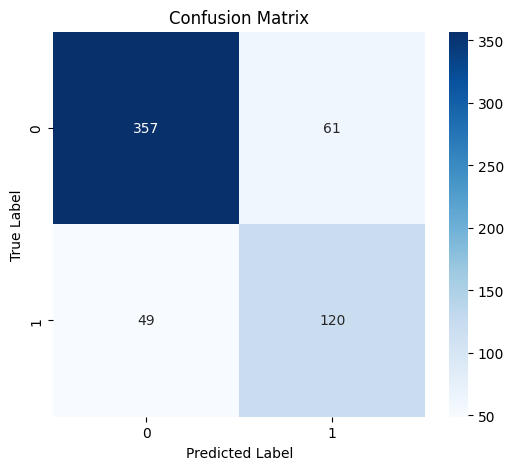


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.87       418
           1       0.66      0.71      0.69       169

    accuracy                           0.81       587
   macro avg       0.77      0.78      0.78       587
weighted avg       0.82      0.81      0.81       587



In [10]:
# Predict the labels.
y_pred = grid.predict(BOW_val)

# Evaluate the model.
precision, recall, f1, _ = precision_recall_fscore_support(val_y, y_pred, average = 'macro')
print(f'Precision: {precision:.6f}')
print(f'Recall   : {recall:.6f}')
print(f'F1 Score : {f1:.6f}')

cm = confusion_matrix(val_y, y_pred)
plt.figure(figsize = (6,5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = set(val_y), yticklabels = set(val_y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n", metrics.classification_report(val_y, y_pred))

### **Error analysis**

In [11]:
incorrect_indices = [i for i, (real, pred) in enumerate(zip(val_y, y_pred)) if real != pred]

print(f"Number of incorrect predictions: {len(incorrect_indices)}\n")
errors = defaultdict(list)
for i in incorrect_indices:
    errors[val_y[i]].append((val_txt[i], y_pred[i]))

for label, misclassified in errors.items():
    print(f"Errors for class {label}:")
    for text, predicted in misclassified[:10]:
        print(f"  - {text} (Predicted: {predicted})")
    print('-' * 50)

Number of incorrect predictions: 110

Errors for class 1:
  - Al perro que se te acerque le parto su madre a si de facil
 (Predicted: 0)
  - @USUARIO Entonces para que quieres estar en sus paises?, mejor vente aca y chinguele cabrona de verdad, maldita sangana.
 (Predicted: 0)
  - Que bueno que hoy juega México, porque tú vales verga, hija de la chingada.
 (Predicted: 0)
  - Mejor que te regalen una buena cogida para que no idolatres a tanto joto de la radio
 (Predicted: 0)
  - Fnatic me acaba de cagar el pick'em, no vuelvo a confiar en los putos europeos
 (Predicted: 0)
  - Y todavía se ofenden porque les dicen 'Putas' las muy putas, lástima que no tiene twitter sino la arrobaba jajajaja
 (Predicted: 0)
  - Ojalá el puñal lo hubiera comentado en la cumbre de su carrera y no cuando ya esta de salida
 (Predicted: 0)
  - Pero un día te voy a tapar el culo mientras te estoy lamiendo la pantunfla a ver si te da una embolia, hija de tu puta madre
 (Predicted: 0)
  - Ya ven putos tarde o tem